In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [20]:
print(os.getcwd())
df = pd.read_csv("./sales_data.csv")
print(df.head())

f:\AI_ML\Python projects\AI Assignments\Week 17
   Sl No        Date  Gender  Age Product Category  Quantity  Price per Unit  \
0      0  24-11-2023    Male   34           Beauty         3              50   
1      1  27-02-2023  Female   26         Clothing         2             500   
2      2  13-01-2023    Male   50      Electronics         1              30   
3      3  21-05-2023    Male   37         Clothing         1             500   
4      4  06-05-2023    Male   30           Beauty         2              50   

   Total Amount  Advertising_Spend  
0           150              51553  
1          1000              53426  
2            30              51943  
3           500              55481  
4           100              50000  


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sl No              1000 non-null   int64 
 1   Date               1000 non-null   object
 2   Gender             1000 non-null   object
 3   Age                1000 non-null   int64 
 4   Product Category   1000 non-null   object
 5   Quantity           1000 non-null   int64 
 6   Price per Unit     1000 non-null   int64 
 7   Total Amount       1000 non-null   int64 
 8   Advertising_Spend  1000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 70.4+ KB
None


In [22]:
print(df.describe())

             Sl No         Age     Quantity  Price per Unit  Total Amount  \
count  1000.000000  1000.00000  1000.000000     1000.000000    1000.00000   
mean    499.500000    41.39200     2.514000      179.890000     459.00000   
std     288.819436    13.68143     1.132734      189.681356     576.08213   
min       0.000000    18.00000     1.000000       25.000000      25.00000   
25%     249.750000    29.00000     1.000000       30.000000      60.00000   
50%     499.500000    42.00000     3.000000       50.000000     135.00000   
75%     749.250000    53.00000     4.000000      300.000000     900.00000   
max     999.000000    64.00000     4.000000      500.000000    5000.00000   

       Advertising_Spend  
count        1000.000000  
mean        52957.920000  
std          5085.875842  
min         50000.000000  
25%         50000.000000  
50%         51326.000000  
75%         54009.250000  
max        150000.000000  


                   Advertising_Spend  Total Amount
Advertising_Spend            1.00000       0.75959
Total Amount                 0.75959       1.00000


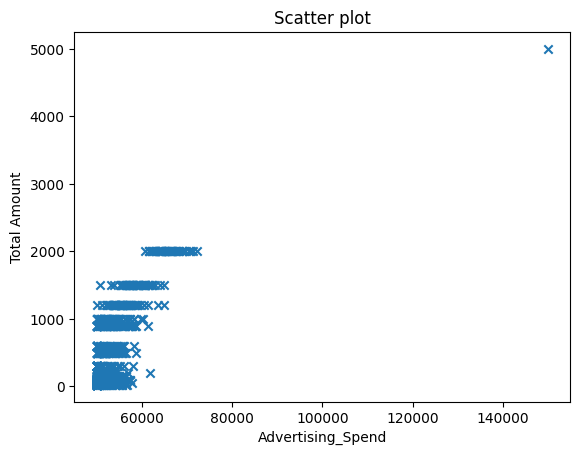

In [23]:
print(df[['Advertising_Spend','Total Amount']].corr())
plt.scatter(df['Advertising_Spend'] , df['Total Amount'],marker="x")
plt.xlabel("Advertising_Spend")
plt.ylabel("Total Amount")
plt.title("Scatter plot")
plt.show()

                   Advertising_Spend  Total Amount
Advertising_Spend            1.00000       0.78893
Total Amount                 0.78893       1.00000


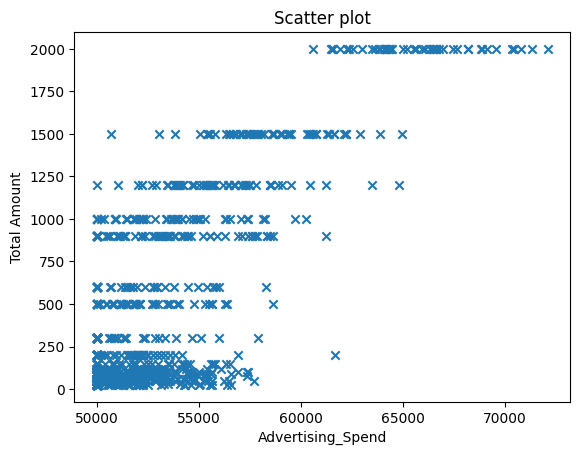

In [24]:
df = df[df['Advertising_Spend'] <149000]
print(df[['Advertising_Spend','Total Amount']].corr())
plt.scatter(df['Advertising_Spend'] , df['Total Amount'],marker="x")
plt.xlabel("Advertising_Spend")
plt.ylabel("Total Amount")
plt.title("Scatter plot")
plt.show()

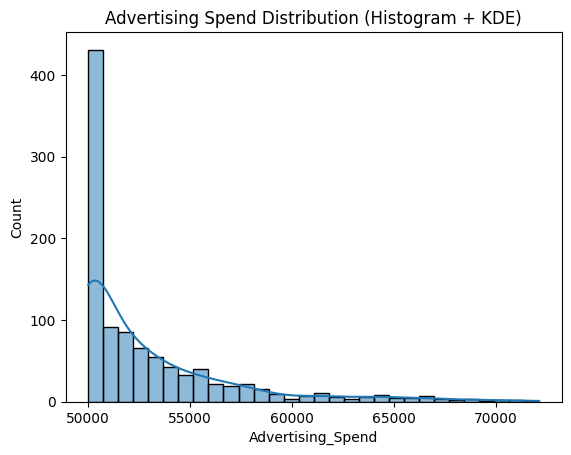

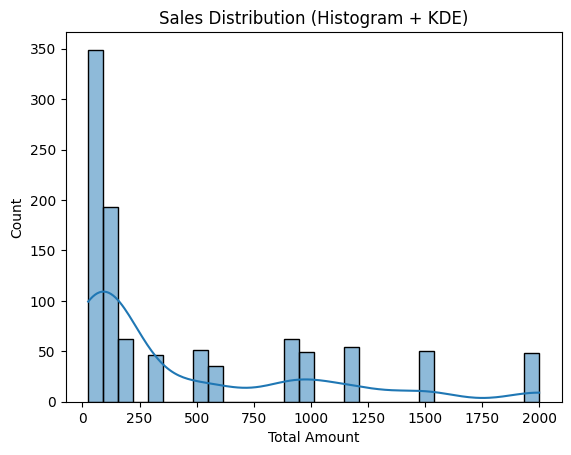

In [25]:

sns.histplot(df["Advertising_Spend"], bins=30, kde=True)
plt.title("Advertising Spend Distribution (Histogram + KDE)")
plt.show()

sns.histplot(df["Total Amount"], bins=30, kde=True)
plt.title("Sales Distribution (Histogram + KDE)")
plt.show()

In [26]:
X = df[["Advertising_Spend"]]
y = df["Total Amount"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

In [27]:

mse_lin = mean_squared_error(y, y_pred)
r2_lin = r2_score(y, y_pred)

print("Linear Regression")
print("MSE:", mse_lin)
print("R2:", r2_lin)

Linear Regression
MSE: 117508.90467090569
R2: 0.622411170645194


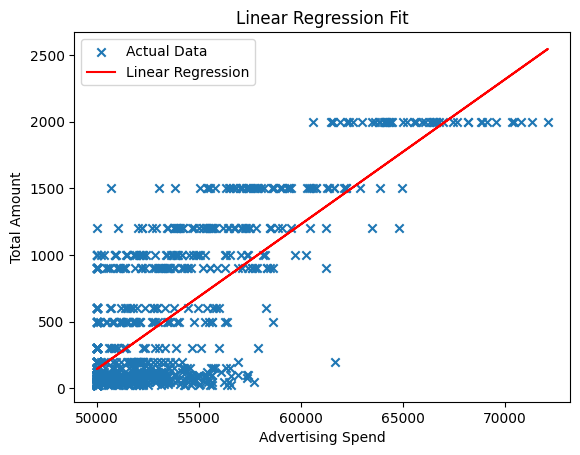

In [28]:
plt.scatter(X, y, marker="x", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Linear Regression")
plt.xlabel("Advertising Spend")
plt.ylabel("Total Amount")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [64]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

y_pred_poly = poly_model.predict(X_poly)

In [69]:
mse_poly = mean_squared_error(y, y_pred_poly)
r2_poly = r2_score(y, y_pred_poly)

print("Polynomial Regression (Degree 2)")
print("MSE:", mse_poly)
print("R2:", r2_poly)

Polynomial Regression (Degree 2)
MSE: 112936.62031199745
R2: 0.6371031933765139


In [70]:
sort_idx = np.argsort(X.values.flatten())
X_sorted = X.values[sort_idx]
y_poly_sorted = y_pred_poly[sort_idx]

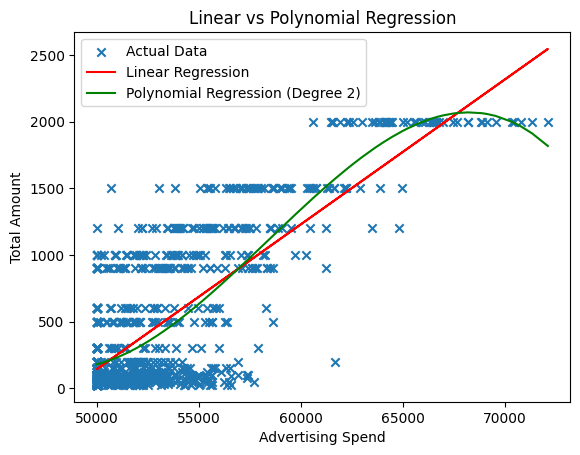

In [73]:
plt.scatter(X, y, marker="x", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Linear Regression")
plt.plot(X_sorted, y_poly_sorted, color="green", label="Polynomial Regression (Degree 2)")
plt.xlabel("Advertising Spend")
plt.ylabel("Total Amount")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

In [33]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (Degree 2)"],
    "MSE": [mse_lin, mse_poly],
    "R2 Score": [r2_lin, r2_poly]
})
comparison

,Model,MSE,R2 Score
0,Linear Regression,117508.904671,0.622411
1,Polynomial Regression (Degree 2),117499.423293,0.622442
